In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from tqdm import tqdm
import requests
import xml.etree.ElementTree as ET
from sklearn.utils import resample
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.MolStandardize import rdMolStandardize
SALT_REMOVER = SaltRemover()
UNCHARGER = rdMolStandardize.Uncharger()
CHOOSER = rdMolStandardize.LargestFragmentChooser()
from pandarallel import pandarallel
import time
import os
import glob
import pandas as pd
import numpy as np
import logging
from collections import defaultdict
from tqdm import tqdm
from sklearn.metrics import cohen_kappa_score, jaccard_score
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)
from pathlib import Path


In [ ]:
PROJECT_ROOT = Path("../../").resolve()
DATA_DIR = PROJECT_ROOT / "data"

toxicity = "reproductive toxicity"
raw_assay_dir = DATA_DIR / "bioassay_raw" / toxicity
processed_dir = DATA_DIR / "processed" / "bioassay" / toxicity
processed_assay_dir = processed_dir / "assay_processed"

processed_dir.mkdir(parents=True, exist_ok=True)
processed_assay_dir.mkdir(parents=True, exist_ok=True)

pfas_pkl_path = DATA_DIR / "pfas_set.pickle"

In [ ]:
pandarallel.initialize(progress_bar=False)
def standardize_smiles(smiles: str):
    import pandas as pd
    import numpy as np
    import pickle
    import os
    import warnings
    warnings.filterwarnings("ignore")
    from rdkit import Chem
    from tqdm import tqdm
    import requests
    import xml.etree.ElementTree as ET
    from sklearn.utils import resample
    from rdkit.Chem.SaltRemover import SaltRemover
    from rdkit.Chem.MolStandardize import rdMolStandardize
    SALT_REMOVER = SaltRemover()
    UNCHARGER = rdMolStandardize.Uncharger()
    CHOOSER = rdMolStandardize.LargestFragmentChooser()
    if not isinstance(smiles, str) or not smiles.strip():
        return np.nan
    
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return np.nan
        mol = SALT_REMOVER.StripMol(mol, dontRemoveEverything=True)
        if "." in smiles:
            mol = CHOOSER.choose(mol)    
        if "+" in smiles or "-" in smiles:      
            mol = UNCHARGER.uncharge(mol) 
        return Chem.MolToSmiles(mol, isomericSmiles=True,canonical=True)
        
    except Exception:
        return np.nan

def process_smiles_data(df, smiles_col='smiles',smiles_standardized_col='standardized_smiles'):
    print(f"Starting parallel processing. Current row count: {len(df)}")
    df[smiles_standardized_col] = df[smiles_col].parallel_apply(standardize_smiles) 
    df.loc[:,'is_changed'] = (df[smiles_col] != df[smiles_standardized_col]) & df[smiles_standardized_col].notna() 
    total = len(df)
    failed = df[smiles_standardized_col].isna().sum()
    changed = df['is_changed'].sum()
    print("-" * 30)
    print(f"Processing complete.")
    print(f"Structures changed (including desalting or normalization): {changed} ({changed/total:.1%})")
    print(f"Parsing failures: {failed} ({failed/total:.1%})")
    
    return df

INFO: Pandarallel will run on 10 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


In [ ]:
smiles = "O=[N+]([O-])c1cc(O)c2ncccc2c1"
mol = Chem.MolFromSmiles(smiles)
mol = UNCHARGER.uncharge(mol) 
Chem.MolToSmiles(mol, isomericSmiles=True,canonical=True)

[14:36:34] Running Uncharger


'O=[N+]([O-])c1cc(O)c2ncccc2c1'

In [ ]:
with open(pfas_pkl_path, "rb") as file:
    pfas_cid_list = pickle.load(file)
def is_pfas(df:pd.DataFrame,CID_col = "PUBCHEM_CID"):
    cids = df[CID_col].tolist()
    results = [1 if cid in pfas_cid_list else 0 for cid in cids]
    df.loc[:,"pfas_target"] = results
    
    return df

In [5]:
def contains_CF(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        
        for bond in mol.GetBonds():
            if bond.GetBondType().name == 'SINGLE' and {bond.GetBeginAtom().GetSymbol(), bond.GetEndAtom().GetSymbol()} == {'C', 'F'}:
                return 1
        return 0

In [6]:
def process_assay(assay_path):
    assay_data = pd.read_csv(assay_path,low_memory=False,)
    assay_csv_num = assay_data[
        assay_data["PUBCHEM_EXT_DATASOURCE_SMILES"].notnull()
    ]
    assay_csv_num.loc[:, "PUBCHEM_CID"] = assay_csv_num["PUBCHEM_CID"].astype(
        np.int64
    )
    assay_csv_num.loc[:, "class"] = (
        assay_csv_num["PUBCHEM_ACTIVITY_OUTCOME"]
        .replace("Inactive", 0)
        .replace("Active", 1)
        .replace("Probe", 1)
        .replace("Inconclusive", -1)
        .replace("Unspecified", -1)
        .fillna(-1)
    ).to_list()
    
    assay_csv_num_need = assay_csv_num.loc[
        :,
        [
            "PUBCHEM_CID",
            "PUBCHEM_EXT_DATASOURCE_SMILES",
            "class",
            "PUBCHEM_ACTIVITY_OUTCOME",
        ],
    ]
    assay_csv_num_need = process_smiles_data(assay_csv_num_need,smiles_col="PUBCHEM_EXT_DATASOURCE_SMILES",smiles_standardized_col="standardized_smiles")
    assay_csv_num_need.dropna(subset=["standardized_smiles"],inplace=True)
    assay_csv_num_need.drop_duplicates(subset=["standardized_smiles"],inplace=True,keep="first")
    
    assay_csv_num_need = assay_csv_num_need[(assay_csv_num_need["class"]==0) | (assay_csv_num_need["class"]==1)]
    assay_csv_num_need["contains_CF"] = assay_csv_num_need["standardized_smiles"].apply(contains_CF)
    assay_csv_num_need = is_pfas(assay_csv_num_need)
    
    return assay_csv_num_need

In [ ]:
assay_list = [p.name for p in raw_assay_dir.glob("*.csv")]

In [ ]:
out_df = pd.DataFrame()
for i in tqdm(assay_list):
    assay_path = raw_assay_dir / i
    assay_data = process_assay(assay_path)
    assay_data.to_csv(processed_assay_dir / f"{Path(i).stem}_processed.csv", index=False)
    
    assay_data_cf = assay_data[assay_data["contains_CF"]==1]
    CF1 = np.sum(assay_data_cf["class"]==1)
    CF0 = np.sum(assay_data_cf["class"]==0)
    assay_data_pfas = assay_data[assay_data["pfas_target"]==1]
    pfas1 = np.sum(assay_data_pfas["class"]==1)
    pfas0 = np.sum(assay_data_pfas["class"]==0)
    desc = pd.DataFrame([[i.split(".csv")[0],CF1,CF0,pfas1,pfas0]],columns=["assay_id","CF1","CF0","pfas1","pfas0"])
    out_df=pd.concat([out_df,desc],axis=0)

  0%|          | 0/129 [00:00<?, ?it/s]

开始并行处理，当前行数: 220365
------------------------------
处理完成！
结构变化（或去盐/规范化）: 219485 (99.6%)
解析失败: 0 (0.0%)


[14:37:55] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
  1%|          | 1/129 [01:33<3:20:17, 93.89s/it]

开始并行处理，当前行数: 9524
------------------------------
处理完成！
结构变化（或去盐/规范化）: 8391 (88.1%)
解析失败: 1 (0.0%)


[14:38:38] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
  2%|▏         | 2/129 [01:41<1:31:52, 43.40s/it]

...

开始并行处理，当前行数: 9163
------------------------------
处理完成！
结构变化（或去盐/规范化）: 8080 (88.2%)
解析失败: 1 (0.0%)


[15:51:50] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4
 99%|█████████▉| 128/129 [1:14:53<00:07,  7.98s/it]

开始并行处理，当前行数: 697


100%|██████████| 129/129 [1:14:58<00:00, 34.87s/it]

------------------------------
处理完成！
结构变化（或去盐/规范化）: 696 (99.9%)
解析失败: 0 (0.0%)


In [12]:
out_df.reset_index(inplace=True, drop=True)

In [ ]:
for i in assay_list:
    assay_id = Path(i).stem
    assay_data = pd.read_csv(processed_assay_dir / f"{assay_id}_processed.csv")
    index = out_df[out_df["assay_id"]==i.split('.csv')[0]].index[0]
    out_df.loc[index,"all_1"]=np.sum(assay_data["class"]==1)
    out_df.loc[index,"all_0"]=np.sum(assay_data["class"]==0)


In [14]:
out_df["PFAS_active_radio"]= out_df["pfas1"]/(out_df["pfas1"]+out_df["pfas0"])

In [15]:
out_df["all_active_radio"]= out_df["all_1"]/(out_df["all_1"]+out_df["all_0"])

In [16]:
out_df["PFAS/ALL_radio"]=out_df["PFAS_active_radio"]/out_df["all_active_radio"]

In [17]:
out_df

,assay_id,CF1,CF0,pfas1,pfas0,all_1,all_0,PFAS_active_radio,all_active_radio,PFAS/ALL_radio
0,1030,1450,17562,310,5733,16016.0,144711.0,0.051299,0.099647,0.514806
1,1159552,49,331,18,104,483.0,6076.0,0.147541,0.073639,2.003564
2,1159555,72,265,30,71,574.0,4116.0,0.297030,0.122388,2.426950
3,1194,4,6,2,4,381.0,428.0,0.333333,0.470952,0.707787
4,1204,1,1,1,0,131.0,93.0,1.000000,0.584821,1.709924
...,...,...,...,...,...,...,...,...,...,...
124,743140,14,354,7,121,198.0,6426.0,0.054688,0.029891,1.829545
125,743195,101,2,91,2,205.0,6.0,0.978495,0.971564,1.007133
126,743202,24,184,9,61,381.0,3908.0,0.128571,0.088832,1.447357
127,743219,65,246,25,82,869.0,4681.0,0.233645,0.156577,1.492208


In [18]:
def get_assay_name(aid):
    assay_base_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug_view/data/bioassay/{int(aid)}/xml/"
    response = requests.get(url=assay_base_url)
    if response.status_code == 200:
        root = ET.fromstring(response.text)
        namespace = {'ns': 'http://pubchem.ncbi.nlm.nih.gov/pug_view'}
        assay_name = root.findall('ns:RecordTitle', namespace)
        time.sleep(2.5)
        return assay_name[0].text

In [20]:
for i in out_df.index:
    aid= out_df.loc[i,'assay_id']
    out_df.loc[i,'assay_name'] = get_assay_name(aid)
    time.sleep(1)

In [ ]:
out_df

,assay_id,CF1,CF0,pfas1,pfas0,all_1,all_0,PFAS_active_radio,all_active_radio,PFAS/ALL_radio,assay_name
0,1032,60,22299,16,6508,669.0,195397.0,0.002452,0.003412,0.718757,Primary biochemical High Throughput Screening ...
1,1053118,8,40,4,7,33.0,195.0,0.363636,0.144737,2.512397,HepG2 Cytotoxicity Assay Measured in Cell-Base...
2,1053125,3,29,0,7,21.0,285.0,0.000000,0.068627,0.000000,HepG2 Cytotoxicity Assay Measured in Cell-Base...
3,1053143,13,362,1,37,125.0,3262.0,0.026316,0.036906,0.713053,HepG2 Cytotoxicity Assay Measured in Cell-Base...
4,1159563,52,91,3,16,213.0,379.0,0.157895,0.359797,0.438844,HepG2 cytotoxicity assay
...,...,...,...,...,...,...,...,...,...,...,...
104,743219,68,256,25,82,869.0,4681.0,0.233645,0.156577,1.492208,qHTS assay for small molecule agonists of the ...
105,743240,22,336,13,98,185.0,5724.0,0.117117,0.031308,3.740784,qHTS assay to identify small molecule antagoni...
106,743395,65,125,14,31,482.0,689.0,0.311111,0.411614,0.755832,HepG2 Cytotoxicity Assay Measured in Cell-Base...
107,743416,76,68,23,17,343.0,473.0,0.575000,0.420343,1.367930,HepG2 Cytotoxicity Assay Measured in Cell-Base...


In [21]:
out_df.to_csv(f"./{toxicity}_assay_desc.csv", index=False)

In [22]:
out_df[(out_df["CF1"]>=25) &(out_df["CF0"]>=25)].sort_values(by=["assay_name","assay_id"],ascending=False).drop_duplicates(subset=["assay_name"],keep="first").to_csv(f"{toxicity}_assay_25.csv")

In [29]:
aid_keep = pd.read_csv(f"./{toxicity}_assay_25.csv")

In [30]:
aid_keep_list = aid_keep.assay_id.to_list()

In [ ]:
def get_assay_similarity_matrix(folder_path, min_overlap=30, kappa_threshold=0.6):
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not csv_files:
        logger.error("No CSV files were found.")
        return

    task_data = {}

    possible_smiles_cols = ['standardized_smiles']
    possible_label_cols = ['class']

    logger.info("Loading and standardizing data...")
    
    for file_path in tqdm(csv_files):
        file_name = os.path.basename(file_path)
        try:
            df = pd.read_csv(file_path)
            s_col = next((c for c in df.columns if c.lower() in possible_smiles_cols), None)
            l_col = next((c for c in df.columns if c.lower() in possible_label_cols), None)
            
            if not s_col or not l_col:
                logger.warning(f"Skipping {file_name}: SMILES or Label column not found")
                continue
                
            df = df.dropna(subset=[s_col, l_col])
        
            current_task_dict = {}
            for _, row in df.iterrows():
                canon_smi = row[s_col]
                current_task_dict[canon_smi] = int(row[l_col])
                
            file_name= "AID:" + file_name.split("_processed.csv")[0] 
            task_data[file_name] = current_task_dict
            
        except Exception as e:
            logger.error(f"Error processing {file_name}: {e}")

    task_names = list(task_data.keys())
    n_tasks = len(task_names)


    logger.info(f"Comparing pairwise similarities among {n_tasks} tasks...")
    results_list = []

    for i in range(n_tasks):
        for j in range(i + 1, n_tasks):
            name_a = task_names[i]
            name_b = task_names[j]
            
            dict_a = task_data[name_a]
            dict_b = task_data[name_b]
            
            common_smiles = set(dict_a.keys()) & set(dict_b.keys())
            n_overlap = len(common_smiles)
            
            if n_overlap < min_overlap:
                continue
            
            y_a = [dict_a[s] for s in common_smiles]
            y_b = [dict_b[s] for s in common_smiles]

            kappa = cohen_kappa_score(y_a, y_b)
            pos_jaccard = jaccard_score(y_a, y_b, average='binary', zero_division=0)
            agreement = np.mean(np.array(y_a) == np.array(y_b))
            if np.isnan(kappa):
                if y_a == y_b:
                    kappa = 1.0
                else:
                    kappa = 0.0
            
            results_list.append({
                "Assay_A": name_a,
                "Assay_B": name_b,
                "Overlap_Molecules": n_overlap,
                "Overlap_Molecules_active": sum((np.array(y_a) == 1) & (np.array(y_b) == 1)),
                "Kappa": kappa,
                "Jaccard": pos_jaccard,
                "Agreement": agreement
            })

    if not results_list:
        logger.warning("No task pairs met the overlap threshold.")
        return pd.DataFrame()

    df_results = pd.DataFrame(results_list)
    return df_results


2026-04-12 16:44:27,123 - 正在加载并标准化数据...
100%|██████████| 129/129 [01:36<00:00,  1.33it/s]
2026-04-12 16:46:03,792 - 开始比对 129 个任务的两两相似度...
c:\Users\29715\anaconda3\envs\mlenviron\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\29715\anaconda3\envs\mlenviron\lib\site-packages\sklearn\metrics\_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
c:\Users\29715\anaconda3\envs\mlenviron\lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\29715\anaconda3\envs\mlenviron\lib\site-packages\sklearn\metrics\_cla

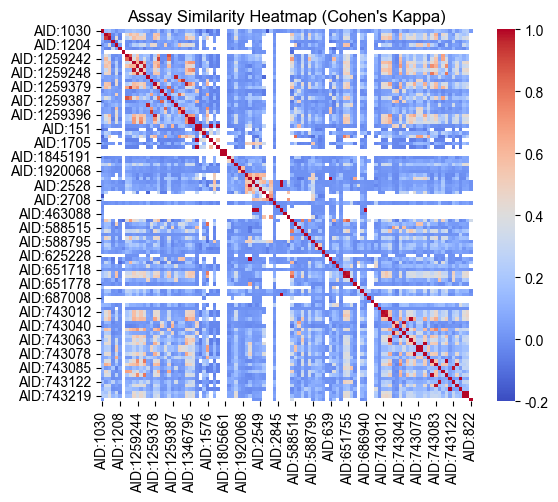

计算完成，已保存 CSV 并展示热力图。


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = get_assay_similarity_matrix(processed_assay_dir, min_overlap=30)
df.to_csv(f"./{toxicity}_assay_similarity_results.csv", index=False)

if not df.empty:
    pivot_table = df.pivot(index="Assay_A", columns="Assay_B", values="Kappa")
    
    matrix = pivot_table.combine_first(pivot_table.T)
    np.fill_diagonal(matrix.values, 1.0)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix, 
        annot=False,   
        fmt=".2f",     
        cmap="coolwarm",  
        vmin=-0.2, vmax=1.0, 
        square=True
    )
    plt.title("Assay Similarity Heatmap (Cohen's Kappa)")
    plt.tight_layout()
    plt.show()
    print("Calculation complete. The CSV was saved and the heatmap was displayed.")
else:
    print("Insufficient data to generate the chart.")

In [ ]:
df_desc = pd.read_csv(f"./{toxicity}_assay_desc.csv")
df_sim = pd.read_csv(f"./{toxicity}_assay_similarity_results.csv")
id_to_name = dict(zip(df_desc['assay_id'].astype(str), df_desc['assay_name']))

In [41]:
id_to_name = dict(zip(df_desc['assay_id'].astype(str), df_desc['assay_name']))
def get_aid_label(aid_label):
        if not isinstance(aid_label, str) or ":" not in aid_label:
            return aid_label
        try:
            _, aid_id = aid_label.split(":")
            aid_id = aid_id.strip() 
            if aid_id in id_to_name:
                assay_name = id_to_name[aid_id]
                return f"{aid_label} - {assay_name}"
            else:
                return aid_label
        except Exception:
            return aid_label

In [42]:
df_sim['Assay_A'] = df_sim['Assay_A'].apply(get_aid_label)
df_sim['Assay_B'] = df_sim['Assay_B'].apply(get_aid_label)

In [44]:
df_sim.to_csv(f"./{toxicity}_assay_similarity_analysis.csv", index=False, encoding='utf-8-sig')

In [ ]:
import pandas as pd
import logging


logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(message)s")
logger = logging.getLogger(__name__)

def filter_redundant_assays(df_sim, kappa_threshold=0.6, priority_keyword="summary"):

    col_a = 'Assay_A'
    col_b = 'Assay_B'
    
    conflicts = df_sim[df_sim['Kappa'] >= kappa_threshold].copy()
    
    if conflicts.empty:
        all_tasks = set(df_sim[col_a]).union(set(df_sim[col_b]))
        return list(all_tasks), []
    all_conflict_nodes = list(conflicts[col_a]) + list(conflicts[col_b])
    conflict_counts = pd.Series(all_conflict_nodes).value_counts().to_dict()
    
    logger.info(f"Found {len(conflicts)} conflicting pairs involving {len(conflict_counts)} assays. Starting greedy deduplication...")


    def is_priority(name):
        return priority_keyword.lower() in str(name).lower()
    drop_set = set()
    conflicts_sorted = conflicts.sort_values(by='Kappa', ascending=False)
    
    for _, row in conflicts_sorted.iterrows():
        a = row[col_a]
        b = row[col_b]
        
        if a in drop_set or b in drop_set:
            continue
        is_a_prio = is_priority(a)
        is_b_prio = is_priority(b)
        
        if is_a_prio and not is_b_prio:
            drop_set.add(b)
            continue
        if is_b_prio and not is_a_prio:
            drop_set.add(a) 
            continue
            
        count_a = conflict_counts.get(a, 0)
        count_b = conflict_counts.get(b, 0)
        
        if count_a > count_b:
            drop_set.add(a) 
        elif count_b > count_a:
            drop_set.add(b) 
        else:
            a_id = a.split("AID:")[1].split(" ")[0].split("-")[0].strip()
            b_id = b.split("AID:")[1].split(" ")[0].split("-")[0].strip()
            if a_id < b_id:
                drop_set.add(a)
            else:
                drop_set.add(b) 

    all_tasks = set(df_sim[col_a]).union(set(df_sim[col_b]))
    keep_list = list(all_tasks - drop_set)
    
    logger.info(f"Deduplication complete. Original: {len(all_tasks)}, removed: {len(drop_set)}, retained: {len(keep_list)}")
    
    return keep_list, list(drop_set)

In [178]:
df_desc

,assay_id,CF1,CF0,pfas1,pfas0,all_1,all_0,PFAS_active_radio,all_active_radio,PFAS/ALL_radio,assay_name
0,1032,60,22299,16,6508,669.0,195397.0,0.002452,0.003412,0.718757,Primary biochemical High Throughput Screening ...
1,1053118,8,40,4,7,33.0,195.0,0.363636,0.144737,2.512397,HepG2 Cytotoxicity Assay Measured in Cell-Base...
2,1053125,3,29,0,7,21.0,285.0,0.000000,0.068627,0.000000,HepG2 Cytotoxicity Assay Measured in Cell-Base...
3,1053143,13,362,1,37,125.0,3262.0,0.026316,0.036906,0.713053,HepG2 Cytotoxicity Assay Measured in Cell-Base...
4,1159563,52,91,3,16,213.0,379.0,0.157895,0.359797,0.438844,HepG2 cytotoxicity assay
...,...,...,...,...,...,...,...,...,...,...,...
104,743219,68,256,25,82,869.0,4681.0,0.233645,0.156577,1.492208,qHTS assay for small molecule agonists of the ...
105,743240,22,336,13,98,185.0,5724.0,0.117117,0.031308,3.740784,qHTS assay to identify small molecule antagoni...
106,743395,65,125,14,31,482.0,689.0,0.311111,0.411614,0.755832,HepG2 Cytotoxicity Assay Measured in Cell-Base...
107,743416,76,68,23,17,343.0,473.0,0.575000,0.420343,1.367930,HepG2 Cytotoxicity Assay Measured in Cell-Base...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
import re

def clean_assay_name(text):
    text = str(text).lower()
    text = re.sub(r'_set\d+', '', text)
    text = re.sub(r'\bset\s*\d+', '', text)
    text = re.sub(r'confirmation', '', text)
    text = re.sub(r'Summary', '', text)
    text = re.sub(r'summary', '', text)
    text = re.sub(r'signaling pathway', '', text)
    text = re.sub(r'qHTS cell viability counter screen', '', text)
    text = re.sub(r'cell viability counter screen', '', text)
    text = re.sub(r'[\d-]+', '', text) 
    
    return text.strip()

def get_text_similarity_matrix(df_desc, name_threshold=0.85):

    ids = df_desc['assay_id'].astype(str).tolist()
    names = df_desc['assay_name'].fillna("").astype(str).tolist()
    cleaned_names = [clean_assay_name(n) for n in names]
    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(cleaned_names)
    
    cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
    
    text_conflicts = []
    n = len(ids)
    for i in range(n):
        for j in range(i + 1, n):
            sim = cosine_sim[i, j]
            if sim >= name_threshold:
                text_conflicts.append({
                    "Assay_A": "AID:" + ids[i] + " - " + names[i], 
                    "Assay_B": "AID:" + ids[j] + " - " + names[j],
                    "Kappa": 1.0,   
                    "Source": "Text_Similarity",
                    "Text_Similarity Score": sim
                })
    
    logger.info(f"Found {len(text_conflicts)} potentially duplicate task pairs based on text similarity.")
    return pd.DataFrame(text_conflicts)

In [49]:
get_text_similarity_matrix(df_desc, name_threshold=0.95)

22:30:28 - INFO - 基于文本相似度发现了 40 对潜在重复任务。


,Assay_A,Assay_B,Kappa,Source,Text_Similarity Score
0,AID:1159552 - qHTS assay to identify small mol...,AID:1159555 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
1,AID:1259241 - qHTS assay to identify small mol...,AID:1259244 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
2,AID:1259241 - qHTS assay to identify small mol...,AID:1259248 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
3,AID:1259242 - qHTS assay to identify small mol...,AID:1259243 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
4,AID:1259242 - qHTS assay to identify small mol...,AID:1259247 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
5,AID:1259243 - qHTS assay to identify small mol...,AID:1259247 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
6,AID:1259244 - qHTS assay to identify small mol...,AID:1259248 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
7,AID:1259364 - qHTS assay to identify small mol...,AID:1259388 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
8,AID:1259377 - qHTS assay to identify small mol...,AID:1259394 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000
9,AID:1259378 - qHTS assay to identify small mol...,AID:1259396 - qHTS assay to identify small mol...,1.0,Text_Similarity,1.000000


In [ ]:
_, dropped_assays_use_kappa= filter_redundant_assays(
    df_sim, 
    kappa_threshold=0.8, 
    priority_keyword="summary"
)
_, dropped_assays_use_text = filter_redundant_assays(
    get_text_similarity_matrix(df_desc, name_threshold=0.95), 
    kappa_threshold=0.9, 
    priority_keyword="summary"
)

22:30:33 - INFO - 发现 36 对冲突，涉及 61 个 Assay。正在进行贪心去重...
22:30:33 - INFO - 去重完成。原始: 106, 剔除: 31, 保留: 75
22:30:33 - INFO - 基于文本相似度发现了 40 对潜在重复任务。
22:30:33 - INFO - 发现 40 对冲突，涉及 62 个 Assay。正在进行贪心去重...
22:30:33 - INFO - 去重完成。原始: 62, 剔除: 34, 保留: 28


In [53]:
len(dropped_assays_use_text),len(dropped_assays_use_kappa)

(34, 31)

In [54]:
len([i.split("AID:")[1].split(" ")[0].split("-")[0].strip() for i in set(dropped_assays_use_kappa + dropped_assays_use_text)])

42

In [ ]:
dropped_aids = [
    i.split("AID:")[1].split(" ")[0].split("-")[0].strip() 
    for i in set(dropped_assays_use_kappa + dropped_assays_use_text) 
]

df_kept = df_desc[~df_desc['assay_id'].astype(str).isin(dropped_aids)]

In [57]:
df_kept.to_csv(f"./{toxicity}_assay_desc_deduplicated_with_kappa_and_text.csv", index=False)

In [61]:
df_kept.shape

(87, 11)

In [58]:
df_kept_25= df_kept[(df_kept["CF1"]>=25) &(df_kept["CF0"]>=25)].sort_values(by=["assay_name","assay_id"],ascending=False).drop_duplicates(subset=["assay_name"],keep="first")

In [59]:
df_kept_25.shape[0]

33

In [60]:
df_kept_25.to_csv(f"{toxicity}_assay_desc_deduplicated_with_kappa_and_text_25.csv",index=False)